In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pickle

In [88]:
import pandas as pd
import random

limit = 6000

benign = []
attack = []

for chunk in pd.read_csv('UDP-Data.csv', chunksize=100000):

    for row in chunk.itertuples(index=False, name=None):
        
        label = row[-2]

        # ---------------- BENIGN ----------------
        if label == 'Benign':

            if len(benign) < limit:
                benign.append(row)

            else:
                r = random.randint(0, len(benign) - 1)

                if r < limit:
                    benign[r] = row

        # ---------------- UDP-attack ----------------
        elif label == 'DrDoS_UDP' or label=='UDP' or label=='UDP-lag':

            if len(attack) < limit:
                attack.append(row)

            else:
                r = random.randint(0, len(attack) - 1)

                if r < limit:
                    attack[r] = row


# Convert to DataFrames
benign_df = pd.DataFrame(benign, columns=chunk.columns)
drdos_df = pd.DataFrame(attack, columns=chunk.columns)

# Combine them
data = pd.concat([benign_df, drdos_df], ignore_index=True)

# Optional: shuffle the final dataset
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

dt = data.copy()

print(data.shape)
print(data.iloc[:, -2].value_counts())

(12000, 80)
Label
Benign       6000
DrDoS_UDP    4943
UDP-lag       801
UDP           256
Name: count, dtype: int64


In [89]:
dt['Label'] = dt['Label'].apply(lambda x: 'Attack' if x=='DrDoS_UDP' or x=='UDP' else 'Benign')

In [90]:
def outlier_removal(a,col):
    q1 = a[col].quantile(0.25)
    q3 = a[col].quantile(0.75)
    iqr = q3-q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    return a[(a[col]>=lower) & (a[col]<=upper)]
dt = outlier_removal(dt,'Flow Duration')
    

**TRAIN AND TEST SPLIT**

In [91]:
from sklearn.model_selection import train_test_split
y = pd.DataFrame(dt['Label'].copy(),columns = ["Label"])
x = dt.drop(columns=['Label'])
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state = 42)

In [92]:
y_test.value_counts()

Label 
Attack    1264
Benign    1247
Name: count, dtype: int64

In [93]:
y_train.value_counts()

Label 
Benign    3812
Attack    3719
Name: count, dtype: int64

In [94]:
# label and class is same just that label is subcategory of class therefore can remove it from above also

In [95]:
# for i in dt.columns:
#     print(i ,dt[i].value_counts()) 
# Total Backward Packets,Total Length of Bwd Packets ,Bwd Packet Length Max,Bwd Packet Length Min ,Bwd Packet Length Mean ,Bwd Packet Length Std 
# ,Bwd IAT Total,Bwd IAT Mean , Bwd IAT Std , Bwd IAT Max ,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags ,Fwd URG Flags ,Bwd URG Flags ,Bwd Header Length 
# ,Bwd Packets/s ,FIN Flag Count ,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count ,CWE Flag Count,ECE Flag Count 
# ,Down/Up Ratio,Avg Bwd Segment Size ,Fwd Avg Bytes/Bulk, Fwd Avg Packets/Bulk ,Fwd Avg Bulk Rate ,Bwd Avg Bytes/Bulk ,Bwd Avg Packets/Bulk 
# ,Bwd Avg Bulk Rate, Subflow Bwd Packets ,Subflow Bwd Bytes ,Init_Win_bytes_forward ,Init_Win_bytes_backward ,Active Mean ,Active Std,Active Max ,Active Min,
# Idle Mean,Idle Std, Idle Max,Idle Min,SimillarHTTP,

In [96]:
x_train.drop([
    'Total Backward Packets',
'Bwd Packets Length Total','Bwd IAT Total','Bwd IAT Mean' ,'Bwd IAT Std','Bwd IAT Max','Bwd IAT Min',
    'Bwd Header Length','Bwd Packets/s','Avg Bwd Segment Size'
,'Subflow Bwd Packets','Subflow Bwd Bytes',
    'Class','Bwd Packet Length Max','Active Mean', 'Active Std', 'Active Max', 'Active Min',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean','SYN Flag Count',
       'Bwd Packet Length Std','RST Flag Count', 'ACK Flag Count',
    'Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count', 'CWE Flag Count',
       'ECE Flag Count','Idle Std', 'Idle Max', 'Idle Min','Idle Mean',
    'Unnamed: 0','PSH Flag Count','FIN Flag Count','Bwd PSH Flags','Down/Up Ratio',
    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
       'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate','Fwd PSH Flags'
], axis=1, inplace=True,errors='ignore')

x_test.drop([
    'Total Backward Packets',
'Bwd Packets Length Total','Bwd IAT Total','Bwd IAT Mean' ,'Bwd IAT Std','Bwd IAT Max','Bwd IAT Min',
    'Bwd Header Length','Bwd Packets/s','Avg Bwd Segment Size'
,'Subflow Bwd Packets','Subflow Bwd Bytes',
    'Class','Bwd Packet Length Max','Active Mean', 'Active Std', 'Active Max', 'Active Min',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean','SYN Flag Count',
       'Bwd Packet Length Std','RST Flag Count', 'ACK Flag Count',
    'Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count', 'CWE Flag Count',
       'ECE Flag Count','Idle Std', 'Idle Max', 'Idle Min','Idle Mean',
    'Unnamed: 0','PSH Flag Count','FIN Flag Count','Bwd PSH Flags','Down/Up Ratio',
    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
       'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate','Fwd PSH Flags'
], axis=1, inplace=True,errors='ignore')

In [97]:
numeric = list()
category = list()
for i in x_train.columns:
    if str(x_train[i].dtype)=='float64' or str(x_train[i].dtype)=='int64':
        numeric.append(i)
    else:
        category.append(i)
len(numeric)

34

In [98]:
x_test.info()
dt.columns

<class 'pandas.core.frame.DataFrame'>
Index: 2511 entries, 6954 to 9716
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Protocol                  2511 non-null   int64  
 1   Flow Duration             2511 non-null   int64  
 2   Total Fwd Packets         2511 non-null   int64  
 3   Fwd Packets Length Total  2511 non-null   float64
 4   Fwd Packet Length Max     2511 non-null   float64
 5   Fwd Packet Length Min     2511 non-null   float64
 6   Fwd Packet Length Mean    2511 non-null   float64
 7   Fwd Packet Length Std     2511 non-null   float64
 8   Flow Bytes/s              2511 non-null   float64
 9   Flow Packets/s            2511 non-null   float64
 10  Flow IAT Mean             2511 non-null   float64
 11  Flow IAT Std              2511 non-null   float64
 12  Flow IAT Max              2511 non-null   float64
 13  Flow IAT Min              2511 non-null   float64
 14  Fwd IAT To

Index(['Unnamed: 0', 'Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [99]:
# fig,ax = plt.subplots(33,2,figsize = (15,200))
# k=0;
# for i in range(0,33):
#     for j in range(0,2):
#         ax[i,j].plot(dt[numeric[k]])
#         ax[i,j].set_title(numeric[k])
#         k+=1;

# plt.show()

In [100]:
numeric_data = pd.DataFrame(x_train,columns=numeric)
categorical_data = pd.DataFrame(x_train,columns=category)
numeric_data.shape

(7531, 34)

**HANDLE OUTLIERS**

In [101]:
# find outliers - by univariate,bivariate analysis
# fig, axes = plt.subplots(33, 2, figsize=(15, 100))
# for i, column in enumerate(numeric_data.columns):
#     sns.kdeplot(numeric_data[column], ax=axes.flat[i])
#     m=numeric_data[column].mean()
#     axes.flat[i].axvline(m,color='red')
#     axes.flat[i].set_title(column)

# plt.tight_layout()
# plt.show()
#outliers-flow duration,fwd packet length min/max/std/mean,Bwd packet length,flow iat std/max/fwd packets and packet length min,ack/rst flag count
#ideal min/max..all,init fwd/bwd win packets - although show little but still better to narrow down them

In [102]:
#Flow Duration


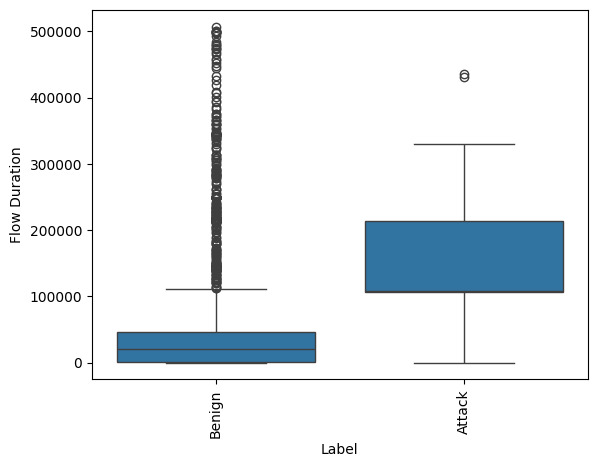

In [103]:
#FWD Packet Length min/max/std/mean
sns.boxplot(x=y_train['Label'],y=x_train['Flow Duration'])
plt.xticks(rotation=90)
plt.show()
#conclusion-> Ddos actually happens for higher flow duration time

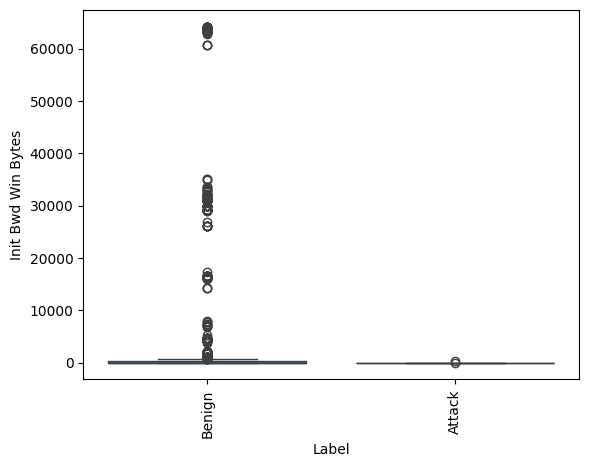

In [104]:
sns.boxplot(x=y_train['Label'],y=x_train['Init Bwd Win Bytes'])
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='Flow IAT Min', ylabel='Density'>

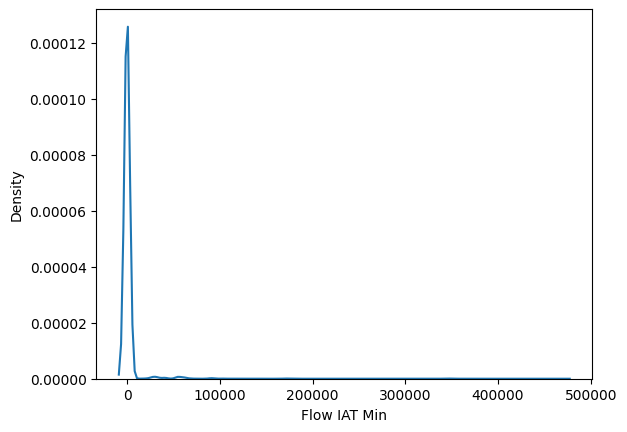

In [105]:
sns.kdeplot(x_train['Flow IAT Min'])

In [106]:
numeric_data.shape

(7531, 34)

In [107]:
k = x_train[x_train['Fwd Packet Length Min']<=1100]


In [108]:
#Fwd Packet Length Max
dt.groupby('Label')['Fwd Packet Length Max'].describe()


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
Attack,4983.0,387.323500,39.427534,0.0,369.0,389.0,393.0,1472.0
Benign,5059.0,79.160704,241.272075,0.0,0.0,33.0,45.0,3491.0


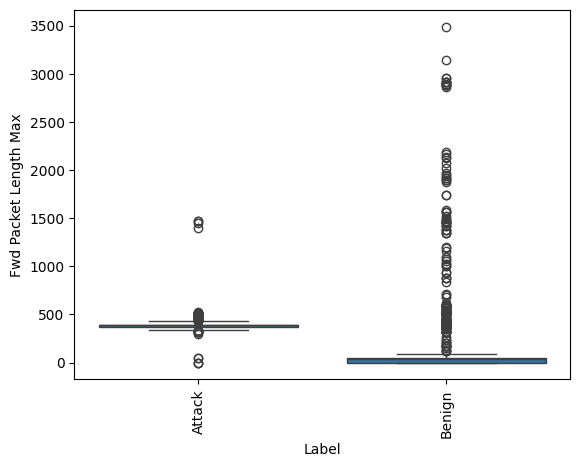

In [109]:
sns.boxplot(
    data=dt,
    x ='Label',
    y = "Fwd Packet Length Max"
)
plt.xticks(rotation=90)
plt.show()

In [110]:
dt.groupby('Label')['Fwd Packet Length Std'].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
Attack,4983.0,28.377354,9.398587,0.0,22.51666,34.063667,35.08846,41.569218
Benign,5059.0,18.340221,83.941593,0.0,0.00000,0.000000,0.00000,1315.418700


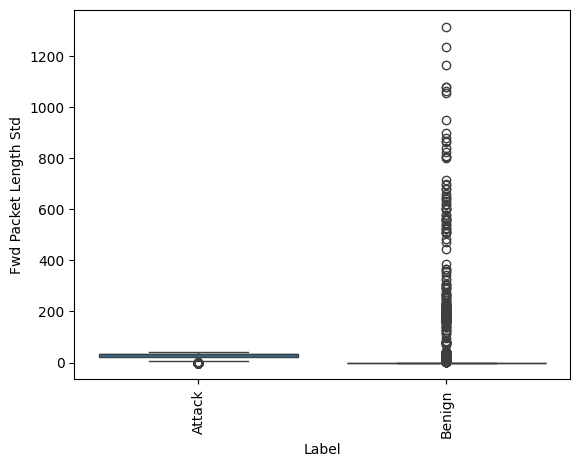

In [111]:
sns.boxplot(
    data=dt,
    x ='Label',
    y = "Fwd Packet Length Std"
)
plt.xticks(rotation=90)
plt.show()

**LABEL ENCODING**

In [112]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
col = y_train.columns
y_train =pd.DataFrame(le.fit_transform(y_train) ,columns =col)
y_test = pd.DataFrame(le.fit_transform(y_test) ,columns =col)
print(y_test.value_counts(),y_train.value_counts())

Label
0        1264
1        1247
Name: count, dtype: int64 Label
1        3812
0        3719
Name: count, dtype: int64


C:\Users\91959\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\91959\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


**FEATURE SELECTION**

**FEATURE SELECTION - BY ANOVA**

In [113]:
#m-1: via setting variance threshold , correlation,chi square test ,anova
for i in x_train.columns:
    print(i,x_train[i].std())
##variance varies a lot therefore standardscaling is required to bring them in same scale  

Protocol 4.811040734607214
Flow Duration 81557.68897655008
Total Fwd Packets 2.948276552789673
Fwd Packets Length Total 1456.4358368310366
Fwd Packet Length Max 236.96959971273128
Fwd Packet Length Min 164.9806844869078
Fwd Packet Length Mean 175.08120960016012
Fwd Packet Length Std 62.786903329910785
Flow Bytes/s 103278872.70407024
Flow Packets/s 344087.6610661653
Flow IAT Mean 23691.85426540973
Flow IAT Std 29051.377293596648
Flow IAT Max 54804.86803968995
Flow IAT Min 17617.870896411685
Fwd IAT Total 86531.7602309916
Fwd IAT Mean 21644.08615552911
Fwd IAT Std 32909.04168846639
Fwd IAT Max 60381.97817961124
Fwd IAT Min 7463.894136058798
Fwd Header Length 234519069.1489919
Fwd Packets/s 343410.43980887963
Packet Length Min 161.9956166009569
Packet Length Max 388.9000609051112
Packet Length Mean 175.07047363995926
Packet Length Std 109.8823662893628
Packet Length Variance 101489.42832939063
Avg Packet Size 216.16680106060892
Avg Fwd Segment Size 175.08120960016012
Subflow Fwd Packets 2

In [114]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = pd.DataFrame(sc.fit_transform(x_train),columns=x_train.columns)

In [115]:
for i in x_train.columns:
    print(i,x_train[i].std())

Protocol 1.0000663988580132
Flow Duration 1.0000663988580127
Total Fwd Packets 1.0000663988580127
Fwd Packets Length Total 1.0000663988580127
Fwd Packet Length Max 1.0000663988580127
Fwd Packet Length Min 1.000066398858013
Fwd Packet Length Mean 1.000066398858013
Fwd Packet Length Std 1.0000663988580127
Flow Bytes/s 1.0000663988580127
Flow Packets/s 1.0000663988580127
Flow IAT Mean 1.0000663988580127
Flow IAT Std 1.0000663988580127
Flow IAT Max 1.0000663988580127
Flow IAT Min 1.0000663988580127
Fwd IAT Total 1.0000663988580127
Fwd IAT Mean 1.0000663988580127
Fwd IAT Std 1.0000663988580127
Fwd IAT Max 1.0000663988580127
Fwd IAT Min 1.0000663988580127
Fwd Header Length 1.0000663988580127
Fwd Packets/s 1.000066398858013
Packet Length Min 1.0000663988580127
Packet Length Max 1.0000663988580127
Packet Length Mean 1.0000663988580127
Packet Length Std 1.000066398858013
Packet Length Variance 1.000066398858013
Avg Packet Size 1.0000663988580127
Avg Fwd Segment Size 1.000066398858013
Subflow Fw

In [116]:
#using anova and chisquare
#anova 
#null hypothesis(N0) = no distinct class difference relationship between features - The mean of the feature is the same across all classes.
#alternate hypothesis(N1) = there exists relationship between features -At least one class has a different mean.
from sklearn.feature_selection import f_classif #performs anova test for classification
f_values,p_values = f_classif(x_train,y_train)
anova_results = pd.DataFrame({
    "Feature":x_train.columns,
    "f_values":f_values,
    "p_values":p_values
})

##if p_value<=0.05(alpha threshold) then we can reject the null hypothesis and the relationship exists between features else not
#higher f value indicates stronger sepration
anova_results[anova_results['p_values']<=0.05].sort_values(by='f_values',ascending=False).head(20)
#since no feature loss , all has a relationship with Label

C:\Users\91959\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Feature,f_values,p_values
21,Packet Length Min,53292.856433,0.000000e+00
5,Fwd Packet Length Min,37979.304851,0.000000e+00
27,Avg Fwd Segment Size,28563.144121,0.000000e+00
6,Fwd Packet Length Mean,28563.144121,0.000000e+00
26,Avg Packet Size,16070.436419,0.000000e+00
23,Packet Length Mean,14796.908027,0.000000e+00
16,Fwd IAT Std,8806.109967,0.000000e+00
15,Fwd IAT Mean,7297.048951,0.000000e+00
17,Fwd IAT Max,7025.864827,0.000000e+00
11,Flow IAT Std,6602.088758,0.000000e+00


**Checking via correlation**

In [117]:
corr_matrix = x_train.corr()
x_train.columns

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Fwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Fwd Header Length', 'Fwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'Avg Packet Size',
       'Avg Fwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes',
       'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 'Fwd Act Data Packets',
       'Fwd Seg Size Min'],
      dtype='object')

In [118]:
high_corr = (
    corr_matrix.abs()
    .where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .stack()
    .sort_values(ascending=False)
)

print(high_corr.head(30))

Total Fwd Packets         Subflow Fwd Packets         1.000000
Fwd Packets Length Total  Subflow Fwd Bytes           1.000000
Subflow Fwd Bytes         Fwd Packets Length Total    1.000000
Subflow Fwd Packets       Total Fwd Packets           1.000000
Fwd Packet Length Mean    Avg Fwd Segment Size        1.000000
Avg Fwd Segment Size      Fwd Packet Length Mean      1.000000
Flow Packets/s            Fwd Packets/s               0.998650
Fwd Packets/s             Flow Packets/s              0.998650
Avg Packet Size           Packet Length Mean          0.990702
Packet Length Mean        Avg Packet Size             0.990702
Packet Length Min         Fwd Packet Length Min       0.978052
Fwd Packet Length Min     Packet Length Min           0.978052
Fwd IAT Max               Fwd IAT Std                 0.975206
Fwd IAT Std               Fwd IAT Max                 0.975206
Fwd Packet Length Min     Avg Fwd Segment Size        0.964329
Fwd Packet Length Mean    Fwd Packet Length Min       0

In [119]:
#since ones >=0.95 pointing to same thing and it is not like they are 
#interdependent and fori=ming a meaning ful value therefore can safely remove one of them 
col_to_remove=['Subflow Fwd Packets',"Flow Packets/s",'Subflow Fwd Bytes','Avg Fwd Segment Size','Packet Length Std','Init Fwd Win Bytes', 
               'Init Bwd Win Bytes','Fwd IAT Max','Fwd IAT Std','Packet Length Mean' ,'Flow IAT Std','Flow IAT Max']

x_train.drop(columns=col_to_remove,inplace=True,errors='ignore')
x_test.drop(columns = col_to_remove,inplace=True,errors='ignore')


In [120]:
dt.groupby('Protocol')['Label']

**FEATURE SELECTION - VIA WRAPPER AND EMBEDDED METHODS**
1. but they depends on ML model used - therefore try some models and check the most frequent ones
2. List of models that we can try:
3.    
       1. Logistic Regression
       2. KNN
       3. SVM
       4. Decission tree
       5. Random Forest
       6. Naive Bayes

In [121]:
x_train.to_csv("x_train.csv",index=False)
y_train.to_csv("y_train.csv",index=False)
x_test.to_csv("x_test.csv",index=False)
y_test.to_csv("y_test.csv",index=False)

print("successfull")
    

successfull
